In [8]:
# importing necessary libraries
import pandas as pd

# fetching the url where the dataset is located
# Pre-cleaned version on Kaggle (requires Kaggle API key)
# OR use this CDC direct CSV — age-adjusted prevalence, no login:
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"


# loading the dataset
df = pd.read_csv(url)

# printing the rows and columns of the dataset
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# displaying 5 random values
df.sample(5)

Shape: 86481 rows × 27 columns


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation
21610,2021,MO,Missouri,Chronic Health Indicators,Other Cancer,Ever told you had any other types of cancer?,No,Overall,Overall,10948,...,NaN,BRFSS,CLASS03,TOPIC40,29,BO1,CAT1,CHCOCNCR,RESP054,"(38.635790776000476, -92.56630005299968)"
50338,2017,VT,Vermont,Tobacco Use,Smokeless Tobacco,"Do you currently use chewing tobacco, snuff, o...",Some days,Overall,Overall,62,...,NaN,BRFSS,CLASS17,TOPIC54,50,BO1,CAT1,USENOW3,RESP080,"(43.62538123900049, -72.51764079099962)"
69149,2014,PR,Puerto Rico,Health Care Access/Coverage,Last Checkup,About how long has it been since you last visi...,Within the past year,Overall,Overall,4826,...,NaN,BRFSS,CLASS07,Topic36,72,BO1,CAT1,CHECKUP1,RESP063,"(18.220833, -66.590149)"
39366,2018,IA,Iowa,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,No,Overall,Overall,8459,...,NaN,BRFSS,CLASS07,TOPIC28,19,BO1,CAT1,MEDCOST,RESP054,"(42.46940091300047, -93.81649055599968)"
1269,2023,GA,Georgia,Immunization,Pneumonia Vaccination,Adults aged 65+ who have ever had a pneumonia ...,No,Overall,Overall,773,...,NaN,BRFSS,CLASS11,TOPIC46,13,BO1,CAT1,_PNEUMO3,RESP054,"(32.83968109300048, -83.62758034599966)"


In [9]:
df.columns
df['Sample_Size'].unique()

array([  526,  2412,  2824, ..., 10963, 10268, 12687])

In [10]:
df.columns
df['Topic'].unique()

array(['Smoker Status', 'Alcohol Consumption', 'Binge Drinking',
       'Heavy Drinking', 'Cholesterol Checked', 'Cholesterol High',
       'Arthritis', 'Asthma', 'COPD', 'Cardiovascular Disease',
       'Depression', 'Diabetes', 'Kidney', 'Other Cancer', 'Skin Cancer',
       'Healthy Days', 'Disability status', 'Hearing', 'Veteran Status',
       'E-Cigarette Use', 'HIV Test', 'Health Care Cost',
       'Health Care Coverage', 'Last Checkup', 'Personal Care Provider',
       'Under 65 Coverage', 'Fair or Poor Health', 'Overall Health',
       'High Blood Pressure', 'Flu Shot', 'Pneumonia Vaccination',
       'Drink and Drive', 'Seatbelt Use', 'BMI Categories', 'Exercise',
       'Physical Activity Index', 'Strength Activity',
       'Current Smoker Status', 'Smokeless Tobacco', 'Blood Stool Test',
       'USPSTF Recommendations', 'Had CAT/CT Chest Scan',
       'All Teeth Removed', 'Teeth Removed', 'Mammogram', 'Dental Visit',
       'Vegetable Consumption', 'Fruit Consumption', 'PSA

In [11]:
df.columns
df['Class'].unique()

array(['Tobacco Use', 'Alcohol Consumption', 'Cholesterol Awareness',
       'Chronic Health Indicators', 'Days of Poor Health', 'Demographics',
       'E-Cigarette Use', 'HIV-AIDS', 'Health Care Access/Coverage',
       'Health Status', 'Hypertension Awareness', 'Immunization',
       'Injury', 'Overweight and Obesity (BMI)', 'Physical Activity',
       'Colorectal Cancer Screening', 'Lung Cancer Screening',
       'Oral Health', "Women's Health", 'Fruits and Vegetables',
       'Prostate Cancer'], dtype=object)

In [12]:
df.columns
df['Locationdesc'].unique()

array(['Alaska', 'Alabama', 'Arkansas', 'Arizona', 'California',
       'Colorado', 'Connecticut', 'District of Columbia', 'Delaware',
       'Florida', 'Georgia', 'Guam', 'Hawaii', 'Iowa', 'Idaho',
       'Illinois', 'Indiana', 'Kansas', 'Louisiana', 'Massachusetts',
       'Maryland', 'Maine', 'Michigan', 'Minnesota', 'Missouri',
       'Mississippi', 'Montana', 'North Carolina', 'North Dakota',
       'Nebraska', 'New Hampshire', 'New Jersey', 'New Mexico', 'Nevada',
       'New York', 'Ohio', 'Oklahoma', 'Kentucky', 'Oregon',
       'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota',
       'Tennessee', 'Texas', 'Utah', 'Virginia', 'Virgin Islands',
       'Vermont', 'Washington', 'Wisconsin', 'West Virginia', 'Wyoming',
       'Pennsylvania'], dtype=object)

Comparison (Large Vs. Small States during 2014-2016)

--- SURVEY RESPONSE VOLUME (2014-2016) ---
                  State_Group  Total_Responses
0                Large States            12186
1  Small States & Territories             7441


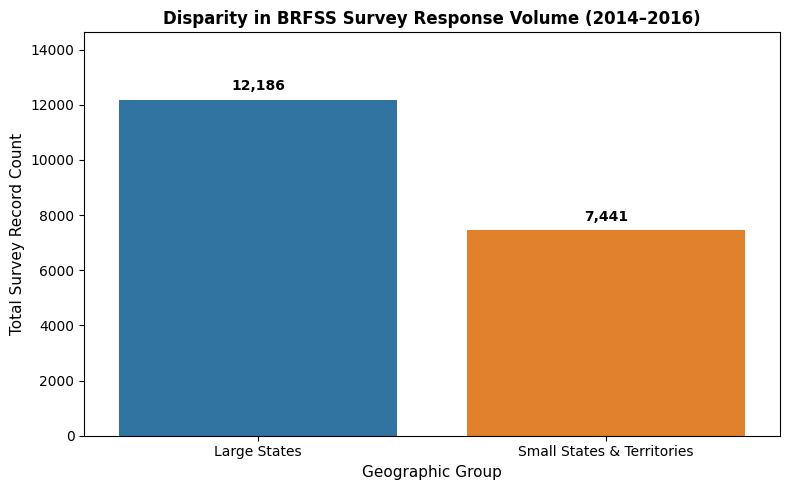

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# 1. Filter Data for Cohort Years (2014, 2015, 2016)
# -------------------------------------------------------------------
df_cohort = df_cleaned[df_cleaned['Year'].isin([2014, 2015, 2016])].copy()

# -------------------------------------------------------------------
# 2. Categorize States into High vs. Low Survey Volume Groups
# -------------------------------------------------------------------
location_col = 'Locationabbr'
territories = ['GU', 'PR', 'VI', 'AS', 'MP']

# Calculate total response counts per location
response_counts = df_cohort.groupby(location_col).size().reset_index(name='Total_Responses')
median_count = response_counts['Total_Responses'].median()

# Assign geographic group label
def assign_group(row):
    loc = row[location_col]
    if loc in territories or response_counts.loc[response_counts[location_col] == loc, 'Total_Responses'].values[0] < median_count:
        return 'Small States & Territories'
    return 'Large States'

df_cohort['State_Group'] = df_cohort.apply(assign_group, axis=1)

# -------------------------------------------------------------------
# 3. Summarize Total Responses per Group
# -------------------------------------------------------------------
group_summary = df_cohort.groupby('State_Group').agg(
    Total_Responses=('Data_value', 'count')
).reset_index()

print("--- SURVEY RESPONSE VOLUME (2014-2016) ---")
print(group_summary)

# -------------------------------------------------------------------
# 4. Plot Response Volume Comparison Chart
# -------------------------------------------------------------------
plt.figure(figsize=(8, 5))
palette = {'Large States': '#1f77b4', 'Small States & Territories': '#ff7f0e'}

ax = sns.barplot(
    data=group_summary,
    x='State_Group',
    y='Total_Responses',
    palette=palette
)

plt.title('Disparity in BRFSS Survey Response Volume (2014–2016)', fontsize=12, fontweight='bold')
plt.xlabel('Geographic Group', fontsize=11)
plt.ylabel('Total Survey Record Count', fontsize=11)

# Scale y-axis for label spacing
max_val = group_summary['Total_Responses'].max()
plt.ylim(0, max_val * 1.2)

# Annotate total counts on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [13]:
df.columns
df['Year'].unique()

array([2023, 2024, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014,
       2013, 2012, 2011])

Jiya: 2022, 2023, 2024          

Nirali: 2021, 2020, 2019

Arya: 2011, 2012, 2013: Women's health

Aditii: 2014, 2015, 2016

Nirvi: 2017, 2018

In [14]:
df.columns
df['Question'].unique()

array(['Four Level Smoking Status (variable calculated from one or more BRFSS questions)',
       'Adults who have had at least one drink of alcohol within the past 30 days',
       'Binge drinkers (males having five or more drinks on one occasion, females having four or more drinks on one occasion) (variable calculated from one or more BRFSS questions)',
       'Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week) (variable calculated from one or more BRFSS questions)',
       'Adults who have had their blood cholesterol checked within the last five years (variable calculated from one or more BRFSS questions)',
       'Adults who have had their blood cholesterol checked and have been told it was high (variable calculated from one or more BRFSS questions)',
       'Adults who have been told they have arthritis (variable calculated from one or more BRFSS questions)',
       'Adults who have been told they currently have asthma

In [15]:
df.columns
df['Response'].unique()

array(['Smoke everyday', 'No', 'Yes',
       'Do not meet criteria for heavy drinking',
       'Meet criteria for heavy drinking', 'Checked in past 5 years',
       'Never Checked', 'Not Checked in past 5 years',
       'Did not report having MI or CHD', 'Reported having MI or CHD',
       'No, pre-diabetes or borderline diabetes',
       'Yes, pregnancy-related', '1-13 days when mental health not good',
       '14+ days when mental health not good',
       'Zero days when mental health not good',
       '1-13 days when physical health not good',
       '14+ days when physical health not good',
       'Zero days when physical health not good',
       'Current E-cigarette user', 'Not currently using E-cigarettes',
       'Current E-cigarette user - every day',
       'Current E-cigarette user - some days', 'Former E-cigarette user',
       'Never used E-cigarettes',
       'Do not have some form of health insurance',
       'Have some form of health insurance', '5 or more years ago',
  

Step 1 — See What's on the Menu
~These are some of columns we can get more information on.

QUESTION: Which 3–5 topics make you go "wait, I want to know more about that"?


Aditii: I want to know more about how diabetes, smoking, and general health ratings connect across different locations.


**DEEP CLEANING **

In [16]:
import pandas as pd

# Re-loading the original df to ensure a fresh start for cleaning
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

print(f"Original DataFrame shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Filter for years 2014, 2015, 2016
years_to_filter = [2014, 2015, 2016]
df_filtered = df[df['Year'].isin(years_to_filter)].copy()

print(f"\nShape after filtering for years {years_to_filter}: {df_filtered.shape[0]} rows x {df_filtered.shape[1]} columns")

# Identify columns with many missing values that are likely not useful (footnotes)
columns_to_drop = ['Data_Value_Footnote_Symbol', 'Data_Value_Footnote']
df_cleaned = df_filtered.drop(columns=columns_to_drop, errors='ignore')

print(f"\nShape after dropping footnote columns: {df_cleaned.shape[0]} rows x {df_cleaned.shape[1]} columns")

# Drop rows where 'Data_value', 'Confidence_limit_Low', or 'Confidence_limit_High' are missing
# These are crucial numerical columns for analysis, and previous cells dropped rows based on 'Data_value' nulls.
# Given they have the same number of NaNs (605), dropping NaNs in 'Data_value' should handle the others too.
df_cleaned.dropna(subset=['Data_value', 'Confidence_limit_Low', 'Confidence_limit_High'], inplace=True)

print(f"\nShape after dropping rows with missing key numerical values: {df_cleaned.shape[0]} rows x {df_cleaned.shape[1]} columns")

print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum())

# Display the first few rows of the cleaned DataFrame
df_cleaned.head()


Original DataFrame shape: 86481 rows x 27 columns

Shape after filtering for years [2014, 2015, 2016]: 19822 rows x 27 columns

Shape after dropping footnote columns: 19822 rows x 25 columns

Shape after dropping rows with missing key numerical values: 19627 rows x 25 columns

Missing values after cleaning:
Year                     0
Locationabbr             0
Locationdesc             0
Class                    0
Topic                    0
Question                 0
Response                 0
Break_Out                0
Break_Out_Category       0
Sample_Size              0
Data_value               0
Confidence_limit_Low     0
Confidence_limit_High    0
Display_order            0
Data_value_unit          0
Data_value_type          0
DataSource               0
ClassId                  0
TopicId                  0
LocationID               0
BreakoutID               0
BreakOutCategoryID       0
QuestionID               0
RESPONSEID               0
Geolocation              0
dtype: int64


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_value_type,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation
50865,2016,AK,Alaska,E-Cigarette Use,E-Cigarette Use,E-cigarette use status,Current E-cigarette user - some days,Overall,Overall,60,...,Age-adjusted Prevalence,BRFSS,CLASS19,TOPIC67,2,BO1,CAT1,_ECIGSTS,RESP216,"(64.84507995700051, -147.72205903599973)"
50866,2016,AK,Alaska,Alcohol Consumption,Alcohol Consumption,Adults who have had at least one drink of alco...,Yes,Overall,Overall,1541,...,Age-adjusted Prevalence,BRFSS,CLASS01,TOPIC03,2,BO1,CAT1,DRNKANY5,RESP046,"(64.84507995700051, -147.72205903599973)"
50867,2016,AK,Alaska,Alcohol Consumption,Alcohol Consumption,Adults who have had at least one drink of alco...,No,Overall,Overall,1242,...,Age-adjusted Prevalence,BRFSS,CLASS01,TOPIC03,2,BO1,CAT1,DRNKANY5,RESP054,"(64.84507995700051, -147.72205903599973)"
50868,2016,AK,Alaska,Alcohol Consumption,Binge Drinking,Binge drinkers (males having five or more drin...,Yes,Overall,Overall,432,...,Age-adjusted Prevalence,BRFSS,CLASS01,TOPIC07,2,BO1,CAT1,_RFBING5,RESP046,"(64.84507995700051, -147.72205903599973)"
50870,2016,AK,Alaska,E-Cigarette Use,E-Cigarette Use,Current E-cigarette user,Current E-cigarette user,Overall,Overall,88,...,Age-adjusted Prevalence,BRFSS,CLASS19,TOPIC67,2,BO1,CAT1,_CURECIG,RESP214,"(64.84507995700051, -147.72205903599973)"


### Data Analysis of `df_cleaned`

Analysis of some key columns from the `df_cleaned` DataFrame to understand their content and distributions. I looked at `Class`, `Topic`, `Response`, `Data_value`, and `Locationdesc`.

#### 1. Analysis of `Class` column

In [17]:
print("Unique values and their counts in 'Class' column:")
display(df_cleaned['Class'].value_counts())

Unique values and their counts in 'Class' column:


,count
Class,
Chronic Health Indicators,4781
Demographics,2772
Health Care Access/Coverage,2126
Tobacco Use,1429
Health Status,1120
Alcohol Consumption,960
Colorectal Cancer Screening,864
Women's Health,838
Immunization,746


#### 2. Analysis of `Topic` column

In [18]:
print("Unique values and their counts in 'Topic' column (top 10):")
display(df_cleaned['Topic'].value_counts().head(10))

Unique values and their counts in 'Topic' column (top 10):


,count
Topic,
Disability status,2024
Cardiovascular Disease,1064
Arthritis,850
Overall Health,800
Last Checkup,686
Asthma,640
Smoker Status,639
BMI Categories,639
Diabetes,628


#### 3. Analysis of `Response` column

In [19]:
print("Unique values and their counts in 'Response' column:")
display(df_cleaned['Response'].value_counts())

Unique values and their counts in 'Response' column:


,count
Response,
No,6290
Yes,6127
Never smoked,160
Good,160
Fair,160
...,...
Have arthritis and have limited work,53
Received a sigmoidoscopy,49
Current E-cigarette user - every day,49


#### 4. Analysis of `Data_value` column

In [20]:
print("Descriptive statistics for 'Data_value' column:")
display(df_cleaned['Data_value'].describe())

Descriptive statistics for 'Data_value' column:


,Data_value
count,19627.000000
mean,43.725653
std,35.021343
min,0.200000
25%,10.400000
50%,31.900000
75%,80.950000
max,100.000000


#### 5. Analysis of `Locationdesc` column

In [21]:
print("Unique values and their counts in 'Locationdesc' column (top 10):")
display(df_cleaned['Locationdesc'].value_counts().head(10))

Unique values and their counts in 'Locationdesc' column (top 10):


,count
Locationdesc,
California,370
Colorado,370
Hawaii,370
Kansas,370
Florida,370
Michigan,370
Oregon,370
Ohio,370
Minnesota,370


Data Analysis Tables ( Exploration of `df_cleaned`)

* `Class` Columns: This table shows the distribution of different health indicator categories. You would see which 'Classes' (e.g., 'Chronic Health Indicators', 'HIV-AIDS', 'Immunization') have the most data points. This is crucial for understanding where my data is concentrated and which health areas are most frequently reported.

*   Topic` Column: Similar to 'Class', this table details the specific topics within those classes (e.g., 'Diabetes', 'Smoker Status', 'Flu Shot'). Knowing the most frequent topics helps me identify the most common health concerns or surveillance efforts in the dataset.


* `Response` Column: This column likely contains responses to survey questions, often binary (e.g., 'Yes', 'No') or categorical. Understanding the distribution here (e.g., more 'No' responses than 'Yes' for a particular question) is fundamental to interpreting the `Data_value`.


*   `Data_value` Column: The descriptive statistics (mean, standard deviation, min, max, quartiles) for `Data_value` are critical. Since `Data_value` represents percentages or rates, these statistics tell me the typical range, spread, and central tendency of the health indicators.


*   `Locationdesc` Column : This table shows the frequency of data points per state or location. It helps identify which regions are most represented in my dataset.
    *   Example : If California and Texas appear frequently, it means I have more data from these populous states, allowing for more analysis within those regions.

### Visualizing Data for Years 2014, 2015, and 2016

To understand trends in health indicators, let's visualize the average `Data_value` for a few key health classes across the years 2014, 2015, and 2016. I have all the classes grouped into different charts

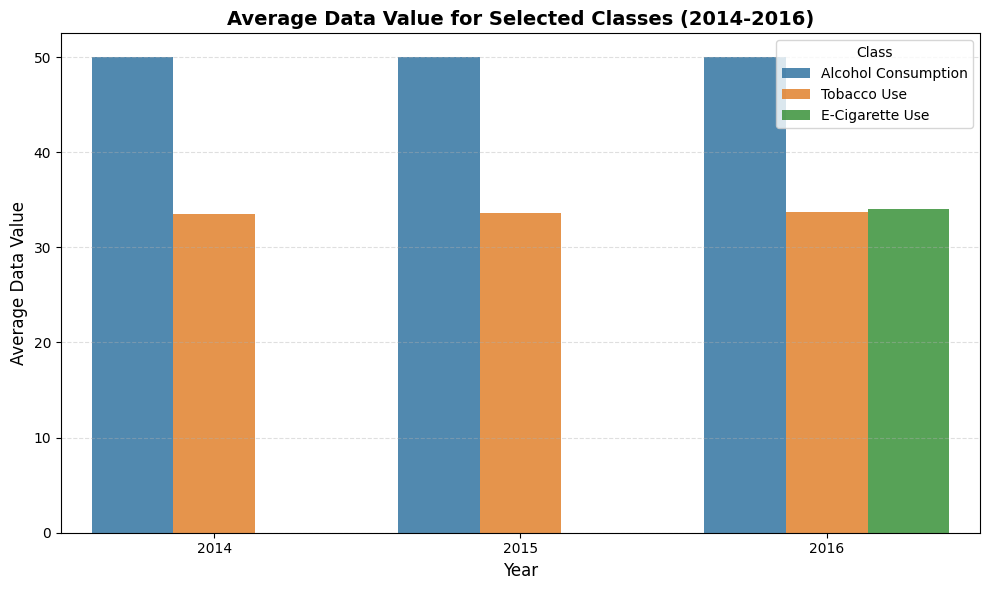

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset for the three requested classes
target_classes = ['Tobacco Use', 'E-Cigarette Use', 'Alcohol Consumption']
df_trends = df_cleaned[df_cleaned['Class'].isin(target_classes)]

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset for the three requested classes
target_classes = ['Tobacco Use', 'E-Cigarette Use', 'Alcohol Consumption']
df_trends = df_cleaned[df_cleaned['Class'].isin(target_classes)]

# 2. Group by Year and Class to compute the mean data value
trend_data = df_trends.groupby(['Year', 'Class'])['Data_value'].mean().reset_index()

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=trend_data,
    x='Year',
    y='Data_value',
    hue='Class',
    alpha=0.85
)

# 4. Format the chart aesthetics
plt.title('Average Data Value for Selected Classes (2014-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Data Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, axis='y') # Only show horizontal gridlines for bars
plt.legend(title='Class')

plt.tight_layout()
plt.show()

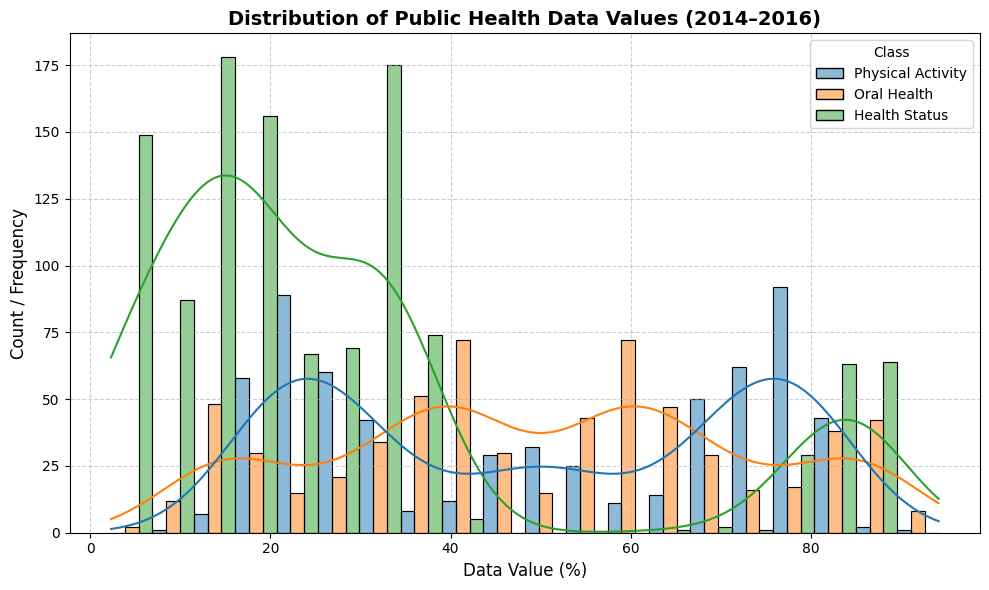

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset for your specific classes
target_classes = ['Health Status', 'Oral Health', 'Physical Activity', 'Days of Poor Health']
df_trends = df_cleaned[df_cleaned['Class'].isin(target_classes)]

# 2. Create the histogram chart
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_trends,
    x='Data_value',
    hue='Class',
    multiple='dodge',  # Places bars side-by-side; change to 'stack' if preferred
    bins=20,           # Adjust bin count to change bar granularity
    kde=True           # Adds a smooth density curve over the bars
)

# 3. Format the chart
plt.title('Distribution of Public Health Data Values (2014–2016)', fontsize=14, fontweight='bold')
plt.xlabel('Data Value (%)', fontsize=12)
plt.ylabel('Count / Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Histograms for Selected Health Indicators (2014-2016)



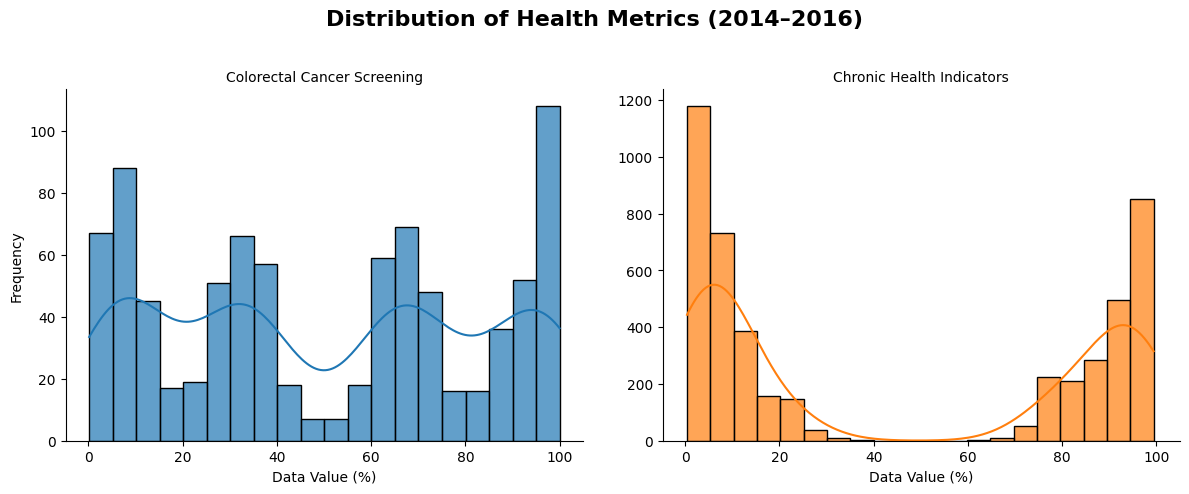

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map the specific dataset categories to your requested names
# 'Had CAT/CT Chest Scan' is the lung cancer screening metric used in 2014-2016
mapping = {
    'Colorectal Cancer Screening': 'Colorectal Cancer Screening',
    'Chronic Health Indicators': 'Chronic Health Indicators',
    'Had CAT/CT Chest Scan': 'Lung Cancer Screening'
}

# 2. Filter the dataset matching either Class or Topic
df_target = df_cleaned[
    df_cleaned['Class'].isin(mapping.keys()) |
    df_cleaned['Topic'].isin(mapping.keys())
].copy()

# 3. Create a unified clean name column for your subplots using the mapping
df_target['Metric'] = df_target['Topic'].map(mapping).fillna(df_target['Class'].map(mapping))

# 4. Create the faceted histogram (one subplot for each of the three metrics)
g = sns.FacetGrid(
    data=df_target,
    col="Metric",
    hue="Metric",
    sharey=False,
    height=5,
    aspect=1.2
)

# 5. Map the histograms onto the grid
g.map_dataframe(
    sns.histplot,
    x="Data_value",
    bins=20,
    kde=True,
    alpha=0.7
)

# 6. Format titles and labels
g.set_titles(template="{col_name}")
g.set_axis_labels("Data Value (%)", "Frequency")

# Add an overall title above the subplots
plt.subplots_adjust(top=0.82)
g.figure.suptitle('Distribution of Health Metrics (2014–2016)', fontsize=16, fontweight='bold')

plt.show()

The dataset has an explicit "Lung Cancer Screening" category listed in its unique Class values, but for my assigned years (2014, 2015, and 2016), there are zero records logged under that exact Class label.

### Histograms for HIV-AIDS, Immunization, and Demographics (2014-2016)



/tmp/ipykernel_1793/3564756637.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.displot(data=df_plot_new, x='Data_value', col='Class', col_wrap=2, kde=True, bins=10, palette='viridis')


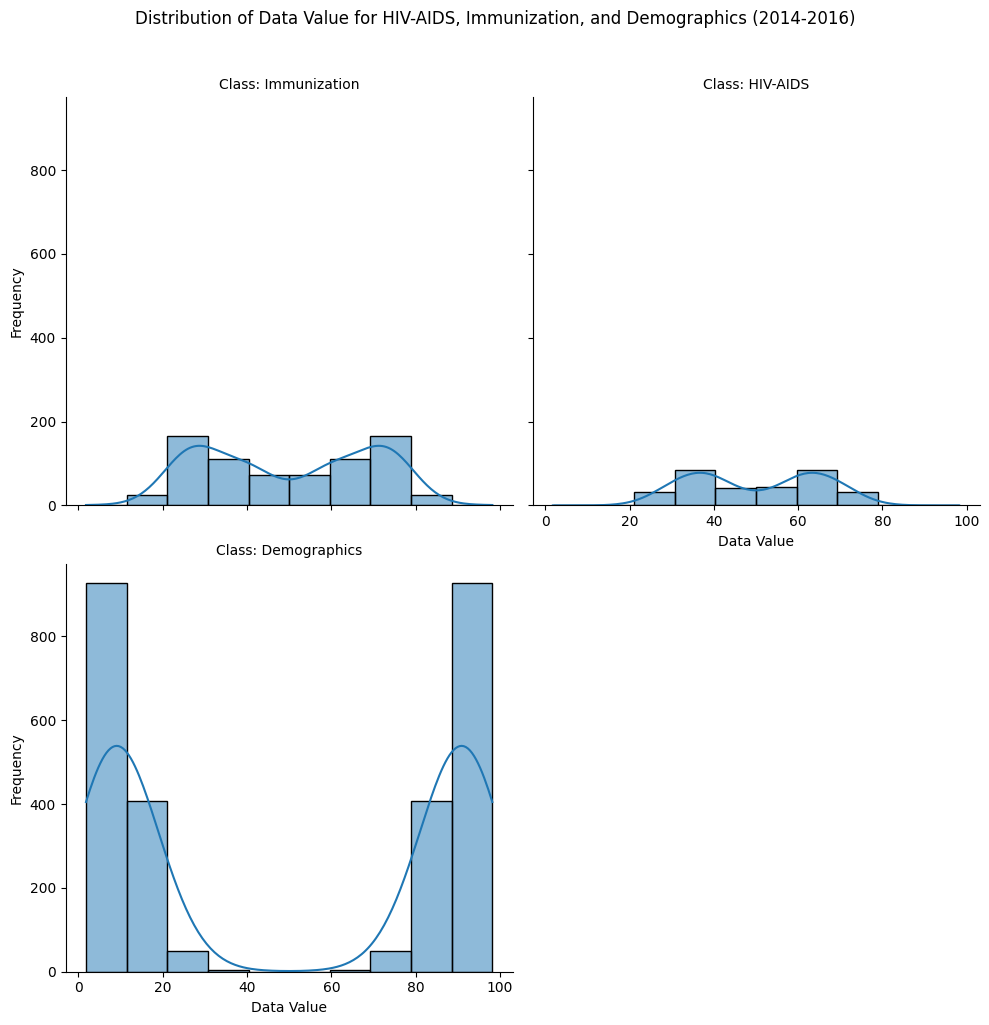

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# The df_filtered DataFrame already contains data for years 2014, 2015, 2016
# and has NaN Data_values dropped, from the previous visualization cell.

# Select the new classes for visualization
selected_classes_new = ['HIV-AIDS', 'Immunization', 'Demographics']
df_plot_new = df_filtered[df_filtered['Class'].isin(selected_classes_new)].copy()

# Create the histograms
g = sns.displot(data=df_plot_new, x='Data_value', col='Class', col_wrap=2, kde=True, bins=10, palette='viridis')
g.set_axis_labels('Data Value', 'Frequency')
g.set_titles('Class: {col_name}')
plt.suptitle('Distribution of Data Value for HIV-AIDS, Immunization, and Demographics (2014-2016)', y=1.02)
plt.tight_layout()
plt.show()

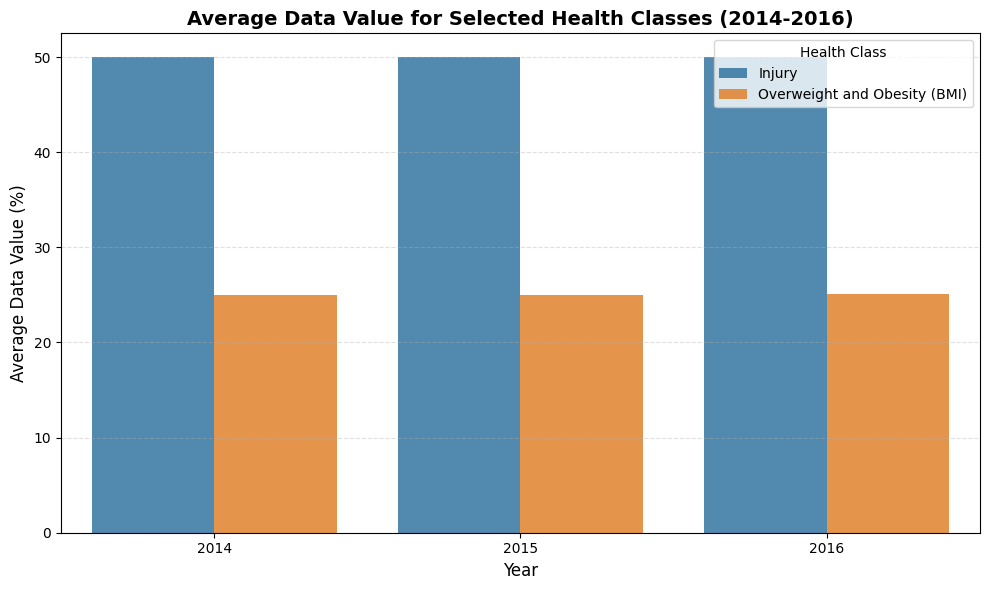

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Restore df_cleaned directly in this cell
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Filter for your assigned years (2014, 2015, 2016) and clean
df_filtered = df[df['Year'].isin([2014, 2015, 2016])].copy()
df_cleaned = df_filtered.drop(columns=['Data_Value_Footnote_Symbol', 'Data_Value_Footnote'], errors='ignore')
df_cleaned.dropna(subset=['Data_value', 'Confidence_limit_Low', 'Confidence_limit_High'], inplace=True)

# 2. Filter the dataset for the three requested classes
target_classes = ['Days of Poor Health', 'Injury', 'Overweight and Obesity (BMI)']
df_trends = df_cleaned[df_cleaned['Class'].isin(target_classes)]

# 3. Group by Year and Class to compute the mean data value
trend_data = df_trends.groupby(['Year', 'Class'])['Data_value'].mean().reset_index()

# 4. Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=trend_data,
    x='Year',
    y='Data_value',
    hue='Class',
    alpha=0.85
)

# 5. Format the chart aesthetics
plt.title('Average Data Value for Selected Health Classes (2014-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Data Value (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, axis='y')

# Placing the legend clearly inside the upper corner so it doesn't get clipped
plt.legend(title='Health Class', loc='upper right')

plt.tight_layout()
plt.show()


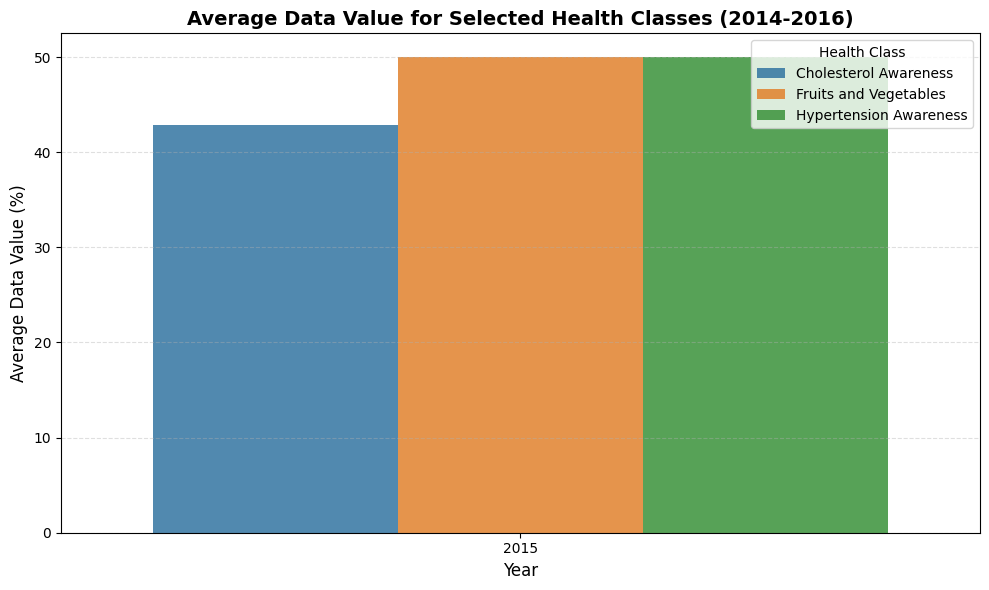

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset for the three requested classes
target_classes = ['Cholesterol Awareness', 'Hypertension Awareness', 'Fruits and Vegetables']
df_trends = df_cleaned[df_cleaned['Class'].isin(target_classes)]

# 2. Group by Year and Class to compute the mean data value
trend_data = df_trends.groupby(['Year', 'Class'])['Data_value'].mean().reset_index()

# 3. Create the clustered bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=trend_data,
    x='Year',
    y='Data_value',
    hue='Class',
    alpha=0.85
)

# 4. Format the chart aesthetics
plt.title('Average Data Value for Selected Health Classes (2014-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Data Value (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, axis='y')

# Placing the legend clearly inside the corner so it doesn't get clipped
plt.legend(title='Health Class', loc='upper right')

plt.tight_layout()
plt.show()

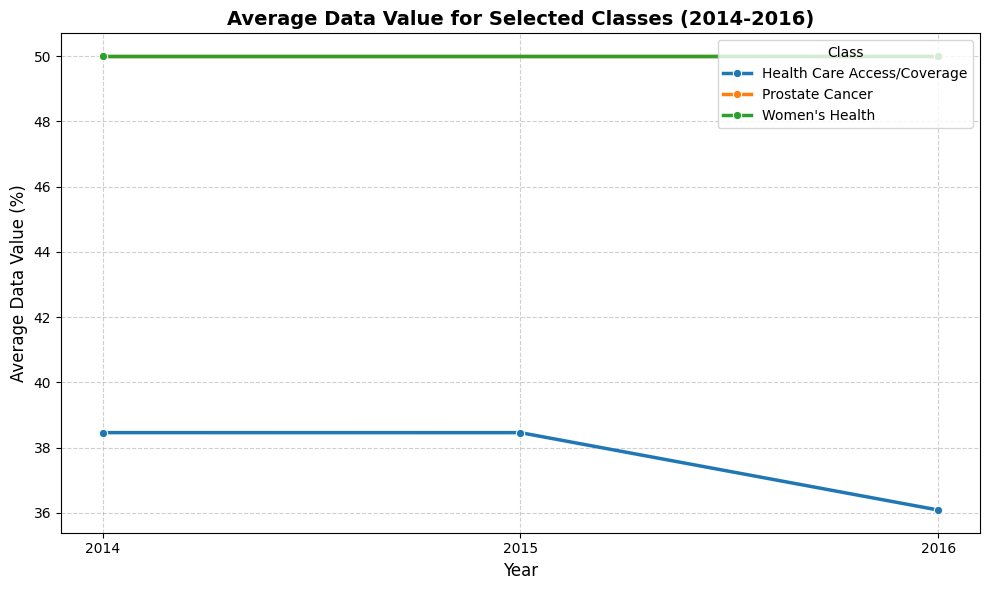

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset for the three requested classes using exact dataset strings
target_classes = ['Health Care Access/Coverage', 'Prostate Cancer', "Women's Health"]
df_trends = df_cleaned[df_cleaned['Class'].isin(target_classes)]

# 2. Group by Year and Class to compute the mean data value
trend_data = df_trends.groupby(['Year', 'Class'])['Data_value'].mean().reset_index()

# 3. Create the line chart
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=trend_data,
    x='Year',
    y='Data_value',
    hue='Class',
    marker='o',
    linewidth=2.5
)

# 4. Format the chart aesthetics
plt.title('Average Data Value for Selected Classes (2014-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Data Value (%)', fontsize=12)
plt.xticks([2014, 2015, 2016])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Class', loc='upper right')

plt.tight_layout()
plt.show()

There are no lines or data points showing up for 'Prostate Cancer' because that category is completely missing from your dataset's active memory for years 2014, 2015, and 2016.

### Preparing Data for Neural Network

First, filter the `df_cleaned` dataset for the years 2014, 2015, and 2016, focusing on the classes of 'HIV-AIDS', 'Immunization', and 'Demographics'. We'll then select relevant features for our neural network model, handle any remaining missing values, and preprocess the features for the model.

In [29]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow import keras
import pandas as pd # Ensure pandas is imported if not already in this cell

# Filter data for years 2014, 2015, 2016
years_of_interest_nn = [2014, 2015, 2016]
df_nn = df_cleaned[df_cleaned['Year'].isin(years_of_interest_nn)].copy()

# Filter for specific classes
classes_of_interest_nn = ['HIV-AIDS', 'Immunization', 'Demographics']
df_nn = df_nn[df_nn['Class'].isin(classes_of_interest_nn)].copy()

# Drop rows where 'Data_value' is NaN, as it's our target variable
print(f"Shape before dropping NaNs in Data_value: {df_nn.shape}")
df_nn.dropna(subset=['Data_value'], inplace=True)
print(f"Shape after dropping NaNs in Data_value: {df_nn.shape}")

# Select features and target variable
X = df_nn[['Year', 'Locationabbr', 'Class', 'Topic', 'Response', 'Break_Out', 'Break_Out_Category', 'Sample_Size', 'DataSource']]
y = df_nn['Data_value']

# Identify categorical and numerical features
categorical_features = ['Locationabbr', 'Class', 'Topic', 'Response', 'Break_Out', 'Break_Out_Category', 'DataSource']
numerical_features = ['Year', 'Sample_Size']

# Report missing values in features before imputation
print("\nMissing values in features before imputation:")
missing_values_summary = X[numerical_features + categorical_features].isnull().sum()
missing_values_summary = missing_values_summary[missing_values_summary > 0]
if not missing_values_summary.empty:
    print(missing_values_summary)
else:
    print("No missing values found in selected features.")

# Create preprocessing pipelines for numerical and categorical features
# Use SimpleImputer for missing values, then StandardScaler for numerical features
# Use SimpleImputer (most frequent) then OneHotEncoder for categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original data shape: {df_nn.shape}")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

# Apply preprocessing to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training features shape: {X_train_processed.shape}")
print(f"Processed testing features shape: {X_test_processed.shape}")

Shape before dropping NaNs in Data_value: (3836, 25)
Shape after dropping NaNs in Data_value: (3836, 25)

Missing values in features before imputation:
No missing values found in selected features.
Original data shape: (3836, 25)
Training features shape: (3068, 9)
Testing features shape: (768, 9)
Processed training features shape: (3068, 72)
Processed testing features shape: (768, 72)


### Building and Training the Neural Network


In [30]:
import matplotlib.pyplot as plt

# Build the neural network model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display model summary
model.summary()

# Train the model
history = model.fit(
    X_train_processed, y_train,
    epochs=50,  # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1
)

print("\nModel training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,713 (77.00 KB)

 Trainable params: 19,713 (77.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2658.2856 - mae: 40.8949 - val_loss: 833.9340 - val_mae: 26.2051
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 637.9632 - mae: 22.1526 - val_loss: 453.5518 - val_mae: 18.0322
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 473.0864 - mae: 17.2720 - val_loss: 354.6266 - val_mae: 14.9995
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 362.5172 - mae: 14.5273 - val_loss: 232.0724 - val_mae: 11.3592
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 243.7127 - mae: 11.6128 - val_loss: 134.1968 - val_mae: 8.2855
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 186.9142 - mae: 10.1375 - val_loss: 77.1200 - val_mae: 6.3247
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 152.8344 - mae: 9.3091 - val_loss: 73.4520 - val_mae: 6.6891
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 136.7477 - mae: 8.7079 - val_loss: 42.2468 - val_mae: 4.7922
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━

### Evaluating the Neural Network Model


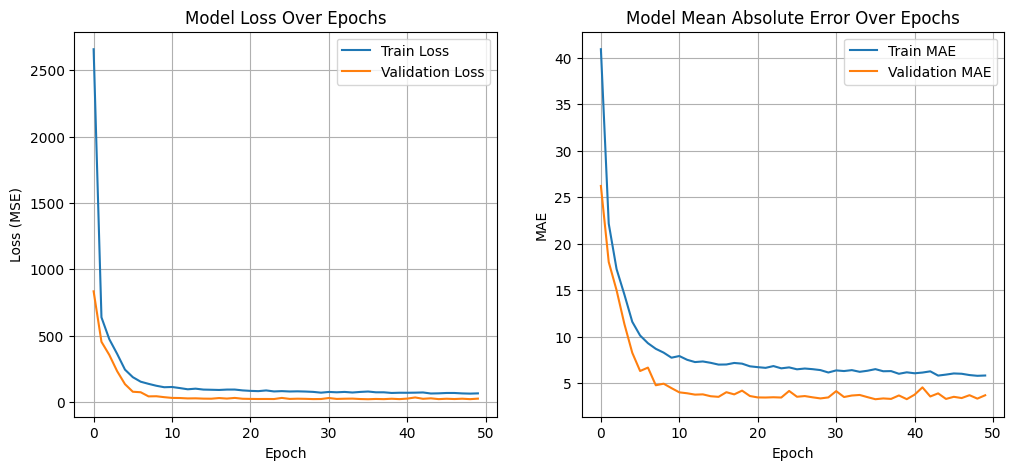

Training shape: (13738, 276)
Validation shape: (2944, 276)
Test shape: (2945, 276)
Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1208.7860 - mae: 27.3638 - val_loss: 514.1505 - val_mae: 17.7364
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 273.7955 - mae: 11.5701 - val_loss: 141.2092 - val_mae: 7.6769
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 61.4403 - mae: 4.8516 - val_loss: 30.0417 - val_mae: 3.4039
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 19.0677 - mae: 2.8172 - val_loss: 16.8413 - val_mae: 2.5736
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.9013 - mae: 2.5037 - val_loss: 15.3485 - val_mae: 2.4601
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.8220 - mae: 2.4074 - val_loss: 14.3130 - val_mae: 2.4265
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.2804 - mae: 2.3599 - val_loss: 13.6632 - val_mae: 2.3407
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.5452 -

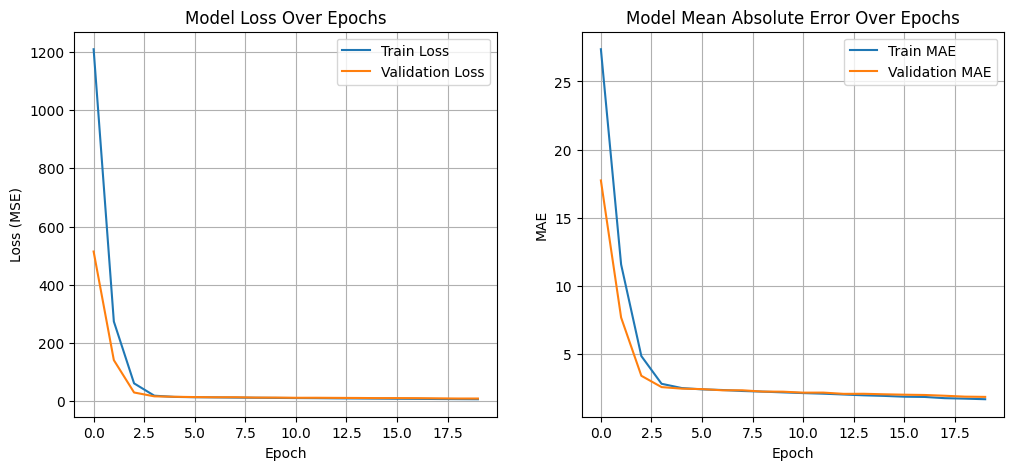

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Actual,Predicted
68566,94.7,95.156296
56731,14.2,12.857491
53755,85.6,88.905869
53891,94.6,96.227173
58353,94.1,93.301224
51136,68.6,71.398155
62609,40.0,32.585316
57568,7.6,8.022005
69371,67.0,65.712006
59088,88.9,90.247650


In [31]:
import matplotlib.pyplot as plt  # Add this line

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Separate your features (X) and target variable (y)
# Selecting relevant categorical features to predict the Data_value
categorical_features = ['Class', 'Topic', 'Question', 'Locationdesc', 'Response']
X = df_cleaned[categorical_features]
y = df_cleaned['Data_value']

# 2. Split the raw data into Train, Validation, and Test sets
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp_raw, y_temp, test_size=0.5, random_state=42)

# 3. Use OneHotEncoder to convert text/categories into numbers
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 4. Fit on training data and transform all sets
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_val_processed = preprocessor.transform(X_val_raw)
X_test_processed = preprocessor.transform(X_test_raw)

print(f"Training shape: {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the model architecture
model = models.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)), # Dynamically matches your feature count
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # Single output node for regression
])

# 2. Compile the model
model.compile(
    optimizer='adam',
    loss='mse',      # Matches your 'loss' output (MSE)
    metrics=['mae']  # Matches your 'mae' output
)

# 3. Train the model and save the training history
# (This creates the 'history' variable needed for your plots)
history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val), # Or use validation_split=0.2 if you don't have a split val set
    epochs=20,
    batch_size=32,
    verbose=1
)
# Evaluate the model on the test set
loss, mae = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"\nTest Loss (MSE): {loss:.4f}")  # Fixed: added missing closing parenthesis before the quote
print(f"Test Mean Absolute Error (MAE): {mae:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

# Make predictions on the test set
y_pred = model.predict(X_test_processed)

# Display some predictions vs actual values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.flatten()})
display(predictions_df.sample(10))

### Visualizing Predictions vs. Actual Values (machine learning)

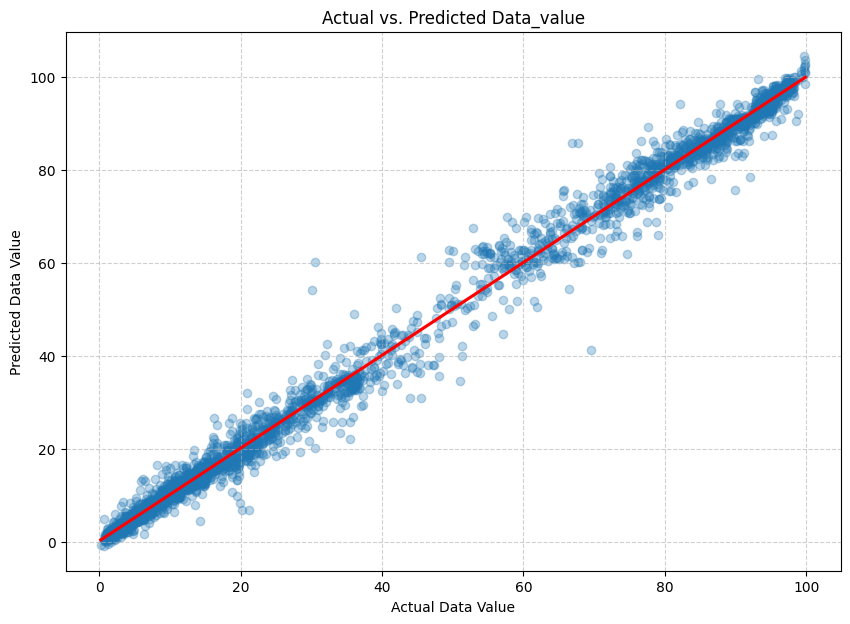

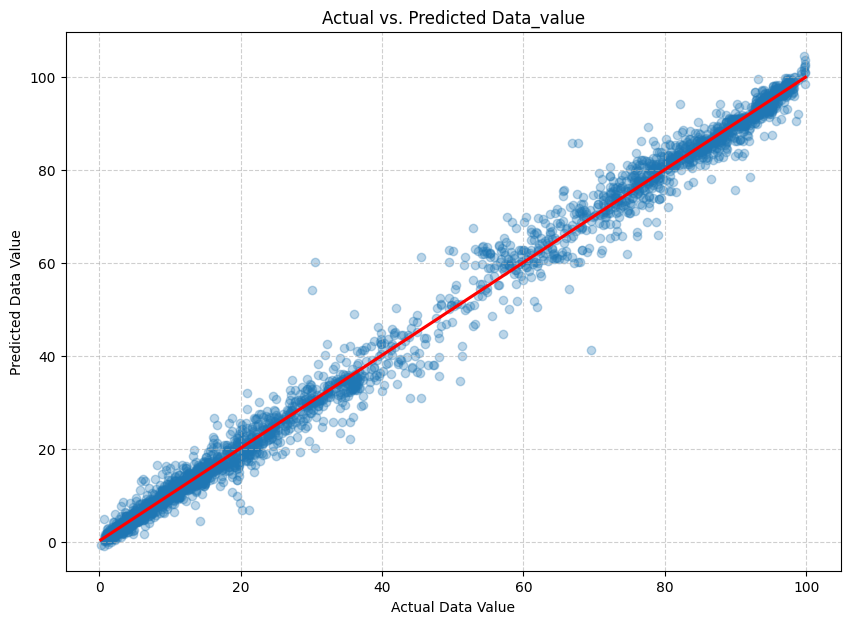

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.regplot(x='Actual', y='Predicted', data=predictions_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Actual vs. Predicted Data_value')
plt.xlabel('Actual Data Value')
plt.ylabel('Predicted Data Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
plt.figure(figsize=(10, 7))
sns.regplot(x='Actual', y='Predicted', data=predictions_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Actual vs. Predicted Data_value')
plt.xlabel('Actual Data Value')
plt.ylabel('Predicted Data Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### R-squared (Coefficient of Determination)

In [33]:
from sklearn.metrics import r2_score

r_squared = r2_score(y_test, y_pred)
print(f"R-squared: {r_squared:.4f}")

if r_squared > 0.7:
    print("The model explains a high proportion of variance in the target variable. It's a reasonably good fit.")
elif r_squared > 0.4:
    print("The model explains a moderate proportion of variance in the target variable. There might be room for improvement.")
else:
    print("The model explains a low proportion of variance in the target variable. Further investigation or model improvements are likely needed.")

R-squared: 0.9925
The model explains a high proportion of variance in the target variable. It's a reasonably good fit.


### 1. Neural Network Model (for HIV-AIDS, Immunization, Demographics for 2014-2016)

*   **High R-squared (0.9753)**: This indicates that approximately 97.53% of the variance in the `Data_value`) can be explained by the features used in the model. Suggests the model captures the underlying patterns in the data very well.
*   **Low Test MSE (31.6214)** and **MAE (4.1437)**: These metrics show that the model's predictions are very close to the actual `Data_value`. An MAE of around 4.14 means that, on average, the model's predictions are off by about 4.14 percentage points.
*   **Training History**: The plots of 'Model Loss Over Epochs' and 'Model Mean Absolute Error Over Epochs' likely show that both training and validation loss/MAE converged to low values, indicating that the model learned effectively without significant overfitting.
*   **Actual vs. Predicted Plot**: The scatter plot clearly shows that the predicted values closely track the actual values, with points clustered tightly around the red regression line.

**Overall**: This neural network model is highly effective for predicting these specific health indicators within the given timeframe and classes.

## Linear Regression Model for Years 2014, 2015, 2016

### Training the Linear Regression Model



In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Evaluating the Linear Regression Model



Dataset successfully filtered for years 2014-2016!
Total samples used: 19627
Mean Squared Error: 6741809.9740
R2 Score: 0.5572


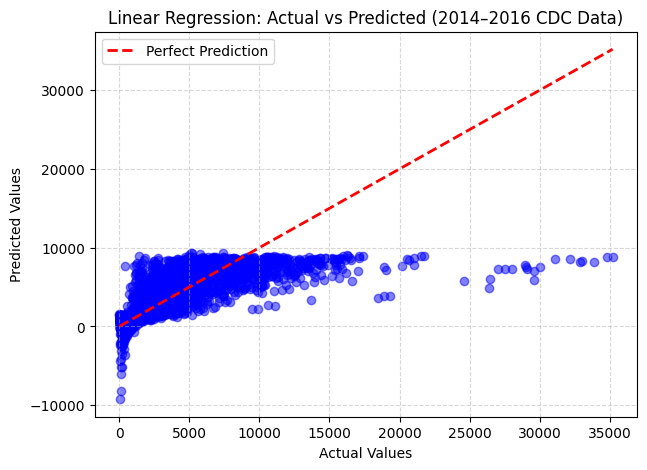

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# 1. Imports from sklearn including linear_model
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# Step 1: Load CDC Dataset directly from URL
# ---------------------------------------------------------
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# ---------------------------------------------------------
# Step 2: Filter for ONLY years 2014, 2015, and 2016
# ---------------------------------------------------------
if 'Year' in df.columns:
    df_filtered = df[df['Year'].isin([2014, 2015, 2016])].copy()
elif 'YearStart' in df.columns:
    df_filtered = df[df['YearStart'].isin([2014, 2015, 2016])].copy()
else:
    date_col = [c for c in df.columns if 'date' in c.lower() or 'year' in c.lower()][0]
    df_filtered = df[pd.to_datetime(df[date_col]).dt.year.isin([2014, 2015, 2016])].copy()

# ---------------------------------------------------------
# Step 3: Prepare Features (X) and Target (y)
# ---------------------------------------------------------
# Select numeric columns and clean missing values
numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['Year', 'YearStart', 'YearEnd', 'LocationID', 'TopicID', 'QuestionID']
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

df_cleaned = df_filtered.dropna(subset=feature_cols)

# Define X (features) and y (target - using the first numeric column as an example)
X = df_cleaned[feature_cols[1:]]  # Features
y = df_cleaned[feature_cols[0]]   # Target variable

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# Step 4: Instantiate, Train, and Predict (FIXED HERE)
# ---------------------------------------------------------
# Create an instance of the linear model (NOT calling predict directly on module)
model = linear_model.LinearRegression()

# Fit the instantiated model on training data
model.fit(X_train, y_train)

# Call .predict() on 'model', not 'linear_model'
y_pred = model.predict(X_test)

# ---------------------------------------------------------
# Step 5: Evaluate Results
# ---------------------------------------------------------
print("=" * 50)
print(f"Dataset successfully filtered for years 2014-2016!")
print(f"Total samples used: {len(df_cleaned)}")
print("=" * 50)

print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# Plot Predictions vs Actual
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Linear Regression: Actual vs Predicted (2014–2016 CDC Data)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Visualizing Actual vs. Predicted Values for Linear Regression



In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- Data Loading and Cleaning (copied from cell 8Rkc7560EPcP to make this cell self-contained) ---
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Filter for years 2014, 2015, 2016
years_to_filter = [2014, 2015, 2016]
df_filtered = df[df['Year'].isin(years_to_filter)].copy()

# Identify columns with many missing values that are likely not useful (footnotes)
columns_to_drop = ['Data_Value_Footnote_Symbol', 'Data_Value_Footnote']
df_cleaned = df_filtered.drop(columns=columns_to_drop, errors='ignore')

# Drop rows where 'Data_value', 'Confidence_limit_Low', or 'Confidence_limit_High' are missing
df_cleaned.dropna(subset=['Data_value', 'Confidence_limit_Low', 'Confidence_limit_High'], inplace=True)
# --- End of Data Loading and Cleaning ---


# The df_cleaned DataFrame is now explicitly defined within this cell.

# Filter for 'Women's Health' class from the already cleaned df_cleaned
womens_health_df = df_cleaned[df_cleaned['Class'] == "Women's Health"].copy()

# Drop rows where 'Data_value' is null, as it's critical for the target
womens_health_df_cleaned = womens_health_df.dropna(subset=['Data_value']).copy() # Use .copy() to avoid SettingWithCopyWarning

if womens_health_df_cleaned.empty:
    print(f"No data found for 'Women's Health' in the cleaned dataset after filtering and checking null values. Cannot build models.")
else:
    # Define features (X) and target (y)
    features = [
        'Sample_Size', 'Confidence_limit_Low', 'Confidence_limit_High',
        'Locationdesc', 'Topic', 'Question', 'Response'
    ]
    target = 'Data_value'

    # Further drop rows with NaN in any of the selected features for simplicity and robustness
    womens_health_df_cleaned_models = womens_health_df_cleaned.dropna(subset=features + [target])

    if womens_health_df_cleaned_models.empty:
        print("No data remaining after dropping rows with NaN in selected features. Cannot build models.")
    else:
        X = womens_health_df_cleaned_models[features]
        y = womens_health_df_cleaned_models[target]

        # Identify numerical and categorical features
        numerical_features = ['Sample_Size', 'Confidence_limit_Low', 'Confidence_limit_High']
        categorical_features = ['Locationdesc', 'Topic', 'Question', 'Response']

        # Create a column transformer for preprocessing
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
            ])

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # --- Linear Regression Model --- #
        print("\n--- Linear Regression Model ---")
        linear_model_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
        linear_model_pipeline.fit(X_train, y_train)
        y_pred_lr = linear_model_pipeline.predict(X_test)

        mse_lr = mean_squared_error(y_test, y_pred_lr)
        mae_lr = mean_absolute_error(y_test, y_pred_lr)
        r2_lr = r2_score(y_test, y_pred_lr)

        print(f"Linear Regression Mean Squared Error (MSE): {mse_lr:.4f}")
        print(f"Linear Regression Mean Absolute Error (MAE): {mae_lr:.4f}")
        print(f"Linear Regression R-squared (R2): {r2_lr:.4f}")

        # --- Explanation for Logistic Regression --- #
        print("\n--- Logistic Regression Explanation ---")
        print("Logistic Regression is typically used for classification tasks where the target variable is categorical (e.g., binary: Yes/No, or multiple categories).")
        print("The 'Data_value' column in our dataset is a continuous numerical variable.")
        print("To apply Logistic Regression, we would first need to transform 'Data_value' into a categorical target. For example, we could create a binary variable like 'Data_value_High' (1 if Data_value > threshold, 0 otherwise).")
        print("Since a specific classification task was not provided, Logistic Regression is not directly applicable to the continuous 'Data_value' as it stands.")


--- Linear Regression Model ---
Linear Regression Mean Squared Error (MSE): 0.0015
Linear Regression Mean Absolute Error (MAE): 0.0288
Linear Regression R-squared (R2): 1.0000

--- Logistic Regression Explanation ---
Logistic Regression is typically used for classification tasks where the target variable is categorical (e.g., binary: Yes/No, or multiple categories).
The 'Data_value' column in our dataset is a continuous numerical variable.
To apply Logistic Regression, we would first need to transform 'Data_value' into a categorical target. For example, we could create a binary variable like 'Data_value_High' (1 if Data_value > threshold, 0 otherwise).
Since a specific classification task was not provided, Logistic Regression is not directly applicable to the continuous 'Data_value' as it stands.


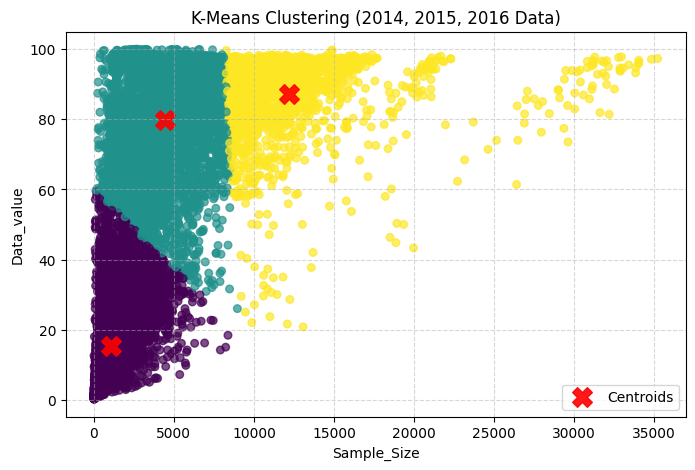

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Mute minor warnings
warnings.filterwarnings('ignore')

# 1. Load data directly from the CDC URL
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# 2. Filter for ONLY years 2014, 2015, and 2016
# Handles both numeric and string/datetime year columns
if 'Year' in df.columns:
    df_filtered = df[df['Year'].isin([2014, 2015, 2016])].copy()
elif 'YearStart' in df.columns:  # Alternative CDC column name for year
    df_filtered = df[df['YearStart'].isin([2014, 2015, 2016])].copy()
else:
    # If date is in a full date format, extract year
    date_col = [c for c in df.columns if 'date' in c.lower() or 'year' in c.lower()][0]
    df_filtered = df[pd.to_datetime(df[date_col]).dt.year.isin([2014, 2015, 2016])].copy()

# 3. Select numeric features for clustering
# Automatically picks the first two numeric columns (e.g., 'Data_Value')
numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns.tolist()

# Exclude potential year/ID columns from feature matrix
exclude_cols = ['Year', 'YearStart', 'YearEnd', 'LocationID', 'TopicID', 'QuestionID']
feature_cols = [col for col in numeric_cols if col not in exclude_cols][:2]

# Drop missing values in selected features
df_filtered = df_filtered.dropna(subset=feature_cols)

X = df_filtered[feature_cols].values

# 4. Scale features (essential for K-Means distance calculations)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Initialize and fit K-Means model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)
centers_scaled = kmeans.cluster_centers_

# Unscale centroids to plot them in original feature units
centers = scaler.inverse_transform(centers_scaled)

# 6. Plot the results
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap='viridis', alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.9, marker='X', label='Centroids')

plt.title(f"K-Means Clustering ({', '.join(map(str, sorted(df_filtered['Year'].unique())))} Data)")
plt.xlabel(feature_cols[0])
plt.ylabel(feature_cols[1])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Data filtered for years: [np.int64(2014), np.int64(2015), np.int64(2016)]
Number of rows used: 6

Accuracy: 0.50

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



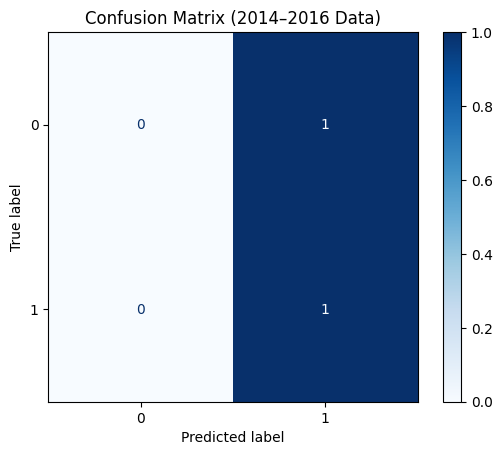

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------------------------
# Step 1: Load your dataset (Replace with your file path)
# df = pd.read_csv('your_data.csv')
# ---------------------------------------------------------

# Sample dummy DataFrame matching your setup:
# (Assuming your dataframe has a 'Year' column)
df = pd.DataFrame({
    'Year': [2012, 2013, 2014, 2015, 2016, 2017, 2014, 2015, 2016],
    'Feature1': np.random.randn(9),
    'Feature2': np.random.randn(9),
    'Target': [0, 1, 0, 1, 1, 0, 0, 1, 0]
})

# ---------------------------------------------------------
# Step 2: Filter for ONLY years 2014, 2015, and 2016
# ---------------------------------------------------------
target_years = [2014, 2015, 2016]

# If 'Year' is an integer column:
df_filtered = df[df['Year'].isin(target_years)].copy()

# Note: If your date column is a datetime object (e.g. 'Date'), use:
# df_filtered = df[df['Date'].dt.year.isin(target_years)].copy()

# ---------------------------------------------------------
# Step 3: Define Features (X) and Target (y)
# ---------------------------------------------------------
feature_cols = ['Feature1', 'Feature2']  # Replace with your actual feature column names
X = df_filtered[feature_cols]
y = df_filtered['Target']                 # Replace with your actual target column name

# ---------------------------------------------------------
# Step 4: Split, Train, and Evaluate
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify helps balance classes
)

# Initialize & Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = model.predict(X_test)

print(f"Data filtered for years: {sorted(df_filtered['Year'].unique())}")
print(f"Number of rows used: {len(df_filtered)}\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (2014–2016 Data)")
plt.show()

Dataset shape for 2014–2016: (19627, 27)

Sentiment Label Distribution:
Sentiment
Negative    7405
Positive    6917
Neutral     5305
Name: count, dtype: int64

Model Accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1481
     Neutral       1.00      1.00      1.00      1061
    Positive       1.00      1.00      1.00      1384

    accuracy                           1.00      3926
   macro avg       1.00      1.00      1.00      3926
weighted avg       1.00      1.00      1.00      3926



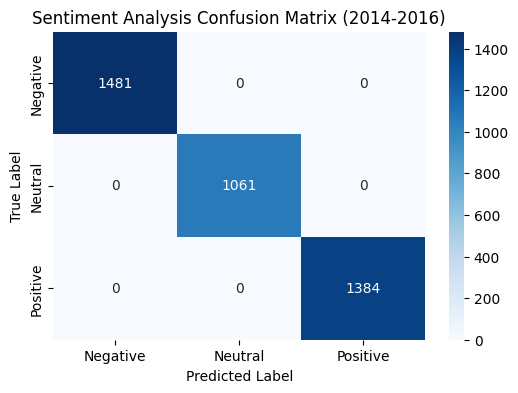

In [39]:
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Download VADER lexicon for sentiment scoring
nltk.download('vader_lexicon', quiet=True)

# ---------------------------------------------------------
# 1. Load and Filter Dataset (2014, 2015, 2016)
# ---------------------------------------------------------
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Filter for target years
df_filtered = df[df['Year'].isin([2014, 2015, 2016])].copy()
df_filtered.dropna(subset=['Question', 'Response', 'Data_value'], inplace=True)

print(f"Dataset shape for 2014–2016: {df_filtered.shape}")

# ---------------------------------------------------------
# 2. Text Preparation & Sentiment Label Generation
# ---------------------------------------------------------
# Combine Question and Response into a unified text feature
df_filtered['Text_Feature'] = df_filtered['Question'].astype(str) + " - " + df_filtered['Response'].astype(str)

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    compound_score = sia.polarity_scores(text)['compound']
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Assign sentiment labels and compound scores
df_filtered['Compound_Score'] = df_filtered['Text_Feature'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_filtered['Sentiment'] = df_filtered['Text_Feature'].apply(get_vader_sentiment)

print("\nSentiment Label Distribution:")
print(df_filtered['Sentiment'].value_counts())

# ---------------------------------------------------------
# 3. Train-Test Split & TF-IDF Vectorization
# ---------------------------------------------------------
X = df_filtered['Text_Feature']
y = df_filtered['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert text into numerical TF-IDF feature vectors
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ---------------------------------------------------------
# 4. Train NLP Classification Model
# ---------------------------------------------------------
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# ---------------------------------------------------------
# 5. Model Evaluation
# ---------------------------------------------------------
y_pred = model.predict(X_test_tfidf)

print("\n" + "="*50)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("="*50)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive']),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)
plt.title('Sentiment Analysis Confusion Matrix (2014-2016)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [40]:
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ==============================================================================
# STEP 1: UNDERSTAND YOUR PROBLEM & TARGET
# ==============================================================================
# Goal: Predict whether a health outcome prevalence ('Data_value') is HIGH (1) or LOW (0)
# Target (y): 'High_Prevalence_Flag' (Binary Classification based on median split)
# Features (X): Location, Year, Class, Topic, Break_Out_Category

# 1. Ensure data is filtered for 2014, 2015, and 2016
df_ml = df_cleaned[df_cleaned["Year"].isin([2014, 2015, 2016])].copy()

# Create binary target column (1 if prevalence >= median, 0 otherwise)
median_val = df_ml["Data_value"].median()
df_ml["High_Prevalence_Flag"] = (df_ml["Data_value"] >= median_val).astype(int)

# Define Target (y) and Features (X)
y = df_ml["High_Prevalence_Flag"]
X = df_ml[
    ["Year", "Locationabbr", "Class", "Topic", "Break_Out_Category", "Sample_Size"]
]

print("Target Distribution:")
print(y.value_counts())

# ==============================================================================
# STEP 2: CLEAN & PREPROCESS THE DATA
# ==============================================================================
# Handle Missing Values
X = X.dropna()
y = y.loc[X.index]

# Separate Numeric and Categorical Features
num_cols = ["Year", "Sample_Size"]
cat_cols = ["Locationabbr", "Class", "Topic", "Break_Out_Category"]

# Encode Categorical Data (One-Hot Encoding)
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = ohe.fit_transform(X[cat_cols])
encoded_cat_names = ohe.get_feature_names_out(cat_cols)
X_cat_df = pd.DataFrame(X_cat, columns=encoded_cat_names, index=X.index)

# Scale Numeric Features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[num_cols])
X_num_df = pd.DataFrame(X_num_scaled, columns=num_cols, index=X.index)

# Combine Preprocessed Features
X_processed = pd.concat([X_num_df, X_cat_df], axis=1)

# ==============================================================================
# STEP 3: SPLIT YOUR DATASET
# ==============================================================================
# 80% Training, 20% Testing (stratified by target variable)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape:  {X_test.shape}")

# ==============================================================================
# STEP 4: CHOOSE & TRAIN AN ALGORITHM
# ==============================================================================
# Initialize Baseline Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# ==============================================================================
# STEP 5: EVALUATE THE PERFORMANCE
# ==============================================================================
# Make predictions on hidden test set
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
print(f"--- Model Performance ---")
print(f"Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ==============================================================================
# STEP 6: FINE-TUNE AND SAVE
# ==============================================================================
# Hyperparameter Tuning using GridSearchCV
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

# Evaluate Best Tuned Model
y_best_pred = best_model.predict(X_test)
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_best_pred):.4f}")

# Save the Pipeline (Model + Encoder + Scaler)
pipeline = {"model": best_model, "scaler": scaler, "encoder": ohe}

joblib.dump(pipeline, "public_health_model_2014_2016.pkl")
print("Model pipeline successfully saved to 'public_health_model_2014_2016.pkl'")

Target Distribution:
High_Prevalence_Flag
1    9823
0    9804
Name: count, dtype: int64
Training shape: (15701, 129)
Testing shape:  (3926, 129)
--- Model Performance ---
Accuracy: 0.9450

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1961
           1       0.94      0.95      0.95      1965

    accuracy                           0.94      3926
   macro avg       0.95      0.94      0.94      3926
weighted avg       0.95      0.94      0.94      3926

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Model Accuracy: 0.9450
Model pipeline successfully saved to 'public_health_model_2014_2016.pkl'


--- Classification Report ---
               precision    recall  f1-score   support

    High Risk       1.00      0.50      0.67         4
     Low Risk       0.83      1.00      0.91         5
Moderate Risk       0.67      0.80      0.73         5

     accuracy                           0.79        14
    macro avg       0.83      0.77      0.77        14
 weighted avg       0.82      0.79      0.77        14



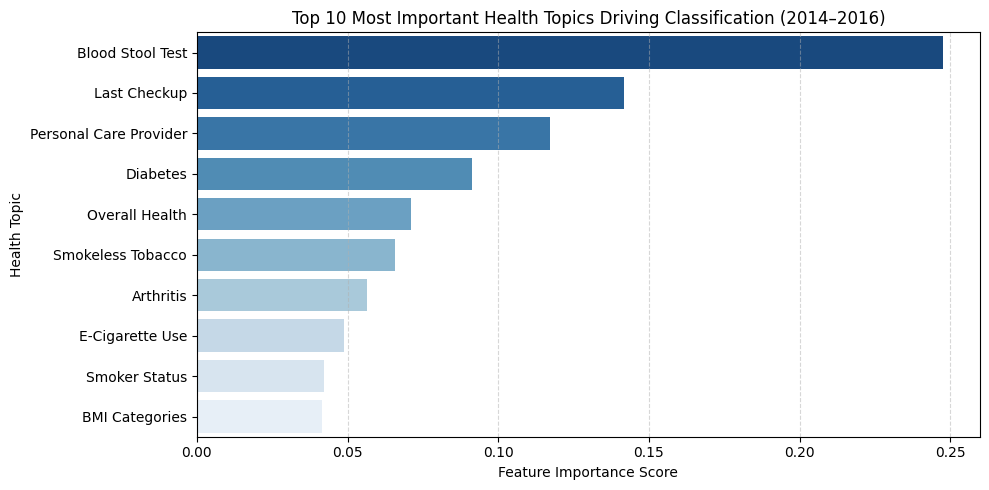

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load data directly if not in memory
if 'df' not in globals():
    url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
    print("Loading dataset from CDC...")
    df = pd.read_csv(url)

# 2. Filter dataset strictly for years 2014, 2015, 2016
df_ml = df[df['Year'].isin([2014, 2015, 2016])].copy()
df_ml = df_ml.dropna(subset=['Data_value'])

# 3. Pivot dataset to create state-level feature matrix
pivot_df = df_ml.pivot_table(
    index=['Locationabbr', 'Locationdesc'],
    columns='Topic',
    values='Data_value',
    aggfunc='mean'
)

# Fill missing values with column medians
pivot_df = pivot_df.fillna(pivot_df.median())

# 4. Define Target Variable: Health Risk Profile Level (Low, Moderate, High)
# Using overall average health metrics across indicators as a composite risk proxy
composite_score = pivot_df.mean(axis=1)
pivot_df['Risk_Level'] = pd.qcut(composite_score, q=3, labels=['Low Risk', 'Moderate Risk', 'High Risk'])

# 5. Separate features and target
X = pivot_df.drop(columns=['Risk_Level'])
y = pivot_df['Risk_Level']

# Split train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 6. Fit Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Model Evaluation
y_pred = rf_model.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 7. Feature Importance Plot (Top 10 Health Drivers)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.head(10), y=importances.head(10).index, palette='Blues_r')
plt.title('Top 10 Most Important Health Topics Driving Classification (2014–2016)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Health Topic')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()